A test to see which number is more suitable for set_num_threads

In [2]:
# import torch
# import time
#
# def benchmark_threads(num_threads, matrix_size=4000, iterations=20):
#     # Set the number of threads for this test run
#     torch.set_num_threads(num_threads)
#
#     # Create two massive random matrices to simulate deep learning workloads
#     A = torch.randn(matrix_size, matrix_size)
#     B = torch.randn(matrix_size, matrix_size)
#
#     # Warmup round (gets the CPU caches loaded and ready)
#     _ = torch.matmul(A, B)
#
#     # Start the actual timer
#     start_time = time.time()
#
#     # Run the heavy math multiple times
#     for _ in range(iterations):
#         _ = torch.matmul(A, B)
#
#     end_time = time.time()
#
#     print(f"Total time with {num_threads} threads: {end_time - start_time:.4f} seconds")
#
# print("--- PyTorch CPU Thread Benchmark ---")
# # Test with 4 threads
# benchmark_threads(4)
#
# # Test with 8 threads
# benchmark_threads(8)

8 threads is faster than 4 threads, so we will use 8 threads for the rest of the code

Cell 1: Imports and Device Setup

In [3]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import time
from ofdm.ccdf import plot_ccdf, plot_ccdf_compare
from ofdm.metrics import calculate_papr, calculate_cm
import matplotlib.pyplot as plt

# Explicitly tell PyTorch to utilize your 8 CPU cores for matrix math
# Check for GPU availability to drastically speed up training
# ! cuda is available only on nvidia gpu
torch.set_num_threads(8)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch using {torch.get_num_threads()} threads on {device}")

PyTorch using 8 threads on cpu


Cell 1.5: Changing the data format from .npz to .pt for faster loading (one-time setup)

In [4]:
# def normalize_and_save():
#     input_dir = "./data_npz/"
#     output_dir = "./data_pt/"
#     os.makedirs(output_dir, exist_ok=True)
#
#     print("Converting .npz to normalized .pt files...")
#     for i in range(100):
#         # print(f"Processing file {i + 1}/100: 16qam_tx_rx_32_part_{i:02d}.npz")
#         print(f"Processing file {i + 1}/100: qpsk_tx_rx_32_part_{i:02d}.npz")
#         # 1. Load the slow .npz file
#         try:
#             # data = np.load(os.path.join(input_dir, f"16qam_tx_rx_32_part_{i:02d}.npz"))
#             data = np.load(os.path.join(input_dir, f"qpsk_tx_rx_32_part_{i:02d}.npz"))
#         except FileNotFoundError:
#             break
#         X_raw = data['tx']
#         Y_raw = data['rx']
#
#         # 2. Extract Real and Imaginary
#         for part_idx, part_name in enumerate(['real', 'imag']):
#             X_batch = torch.tensor(X_raw[part_idx, :, :], dtype=torch.float32)
#             Y_batch = torch.tensor(Y_raw[part_idx, :, :], dtype=torch.float32)
#
#             # 3. Normalize once and for all
#             X_min, X_max = X_batch.min(), X_batch.max()
#             Y_min, Y_max = Y_batch.min(), Y_batch.max()
#
#             X_norm = 2.0 * ((X_batch - X_min) / (X_max - X_min)) - 1.0 if X_max != X_min else X_batch
#             Y_norm = 2.0 * ((Y_batch - Y_min) / (Y_max - Y_min)) - 1.0 if Y_max != Y_min else Y_batch
#
#             # 4. Save as a hyper-fast PyTorch file
#             # torch.save((X_norm, Y_norm), os.path.join(output_dir, f"16qam_tx_rx_32_part_{i:02d}_{part_name}.pt"))
#             torch.save((X_norm, Y_norm), os.path.join(output_dir, f"qpsk_tx_rx_32_part_{i:02d}_{part_name}.pt"))
#
#     print("Done! You never have to do this math again.")
#
# normalize_and_save()

Cell 2: Custom Activation Function

In [5]:
class TriangularActivation(nn.Module):
    """
    Implements the triangular activation function used in the paper's hidden layers.
    Mathematically equivalent to MATLAB's 'tribas': f(x) = max(1 - |x|, 0)
    """
    def forward(self, x):
        return torch.clamp(1.0 - torch.abs(x), min=0.0)

Cell 3: Highly Optimized Dataset Class

This is fast as it works with .pt directly without conversion

In [6]:
class FastOFDMDataset(Dataset):
    def __init__(self, pt_folder_path, part='real'):
        self.folder_path = pt_folder_path
        self.part = part

    def __len__(self):
        return 100 # Assuming exactly 100 pre-computed .pt files

    def __getitem__(self, idx):
        # Instantly loads the pre-normalized tensors directly into memory!
        # file_path = os.path.join(self.folder_path, f"16qam_tx_rx_32_part_{idx:02d}_{self.part}.pt")
        file_path = os.path.join(self.folder_path, f"qpsk_tx_rx_32_part_{idx:02d}_{self.part}.pt")
        X_norm, Y_norm = torch.load(file_path, weights_only=True)
        return X_norm, Y_norm

Cell 4: Neural Network Architecture

In [7]:
class NNICFMapper(nn.Module):
    def __init__(self, input_size):
        super(NNICFMapper, self).__init__()
        # First hidden layer: 2 neurons
        self.hidden1 = nn.Linear(input_size, 2)
        # Second hidden layer: 1 neuron
        self.hidden2 = nn.Linear(2, 1)
        # Output layer: Maps back to the original subcarrier points
        self.output = nn.Linear(1, input_size)
        # Custom triangular activation
        self.activation = TriangularActivation()

    def forward(self, x):
        x = self.activation(self.hidden1(x))
        x = self.activation(self.hidden2(x))
        x = self.output(x) # Standard linear output
        return x

Cell 5: Initialization and DataLoaders

In [8]:
# # --- Configuration ---
# # Update this path to where your 100 files are saved!
# file_directory = "./data_pt/"
#
# # Initialize DataLoaders with asynchronous loading (num_workers) and rapid memory transfer
# train_dataset_real = FastOFDMDataset(file_directory, part='real')
# train_loader_real = DataLoader(
#     train_dataset_real,
#     batch_size=None, # batch_size is None because the dataset returns a full batch of 10,000
#     shuffle=True,
#     num_workers=0,   # Adjust between 2-4 based on your CPU cores
#     pin_memory=torch.cuda.is_available()
# )
#
# train_dataset_imag = FastOFDMDataset(file_directory, part='imag')
# train_loader_imag = DataLoader(
#     train_dataset_imag,
#     batch_size=None,
#     shuffle=True,
#     num_workers=0,
#     pin_memory=torch.cuda.is_available()
# )
#
# # 1024 features based on N=256 and oversampling J=4
# input_features = 1024
#
# # Initialize models and send them to the GPU/device
# Mod_Re_NN = NNICFMapper(input_features).to(device)
# Mod_Im_NN = NNICFMapper(input_features).to(device)
#
# # Standard Mean Squared Error loss and Adam optimizer
# criterion = nn.MSELoss()
# optimizer_real = optim.Adam(Mod_Re_NN.parameters(), lr=0.001)
# optimizer_imag = optim.Adam(Mod_Im_NN.parameters(), lr=0.001)

In [9]:
# --- Configuration ---
# Update this path to where your 100 files are saved!
file_directory = "./data_pt/"

# Initialize DataLoaders with asynchronous loading (num_workers) and rapid memory transfer
full_dataset_real = FastOFDMDataset(file_directory, part='real')
train_dataset_real = Subset(full_dataset_real, range(80))  # Use the first 80 files for training
train_loader_real = DataLoader(
    train_dataset_real,
    batch_size=None, # batch_size is None because the dataset returns a full batch of 10,000
    shuffle=True,
    num_workers=0,   # Adjust between 2-4 based on your CPU cores
    pin_memory=torch.cuda.is_available()
)

full_dataset_imag = FastOFDMDataset(file_directory, part='imag')
train_dataset_imag = Subset(full_dataset_imag, range(80))  # Use the first 80 files for training
train_loader_imag = DataLoader(
    train_dataset_imag,
    batch_size=None,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

# 1024 features based on N=256 and oversampling J=4
input_features = 1024

# Initialize models and send them to the GPU/device
Mod_Re_NN = NNICFMapper(input_features).to(device)
Mod_Im_NN = NNICFMapper(input_features).to(device)

# Standard Mean Squared Error loss and Adam optimizer
criterion = nn.MSELoss()
optimizer_real = optim.Adam(Mod_Re_NN.parameters(), lr=0.005)
optimizer_imag = optim.Adam(Mod_Im_NN.parameters(), lr=0.005)

Not using .compile() is actually better, it also avoids the hassle of cl.exe and needing to run "x64 Native Tools Command Prompt for VS".

dont know if thats the case with gpu or not tho

Cell 6: Training Loop (Real Module)

--- Starting Training for the Real NN Module ---
Real Module | Epoch 1/100 | Loss: 0.261940 | Time: 12.05 seconds
Real Module | Epoch 2/100 | Loss: 0.114499 | Time: 9.70 seconds
Real Module | Epoch 3/100 | Loss: 0.081606 | Time: 9.67 seconds
Real Module | Epoch 4/100 | Loss: 0.075901 | Time: 10.41 seconds
Real Module | Epoch 5/100 | Loss: 0.075174 | Time: 10.34 seconds
Real Module | Epoch 6/100 | Loss: 0.075097 | Time: 10.04 seconds
Real Module | Epoch 7/100 | Loss: 0.075086 | Time: 9.58 seconds
Real Module | Epoch 8/100 | Loss: 0.075085 | Time: 9.64 seconds
Real Module | Epoch 9/100 | Loss: 0.075081 | Time: 9.78 seconds
Real Module | Epoch 10/100 | Loss: 0.075082 | Time: 9.86 seconds
Real Module | Epoch 11/100 | Loss: 0.075078 | Time: 11.00 seconds
Real Module | Epoch 12/100 | Loss: 0.075075 | Time: 11.31 seconds
Real Module | Epoch 13/100 | Loss: 0.075071 | Time: 14.57 seconds
Real Module | Epoch 14/100 | Loss: 0.075075 | Time: 23.08 seconds
Real Module | Epoch 15/100 | Loss: 0.07506

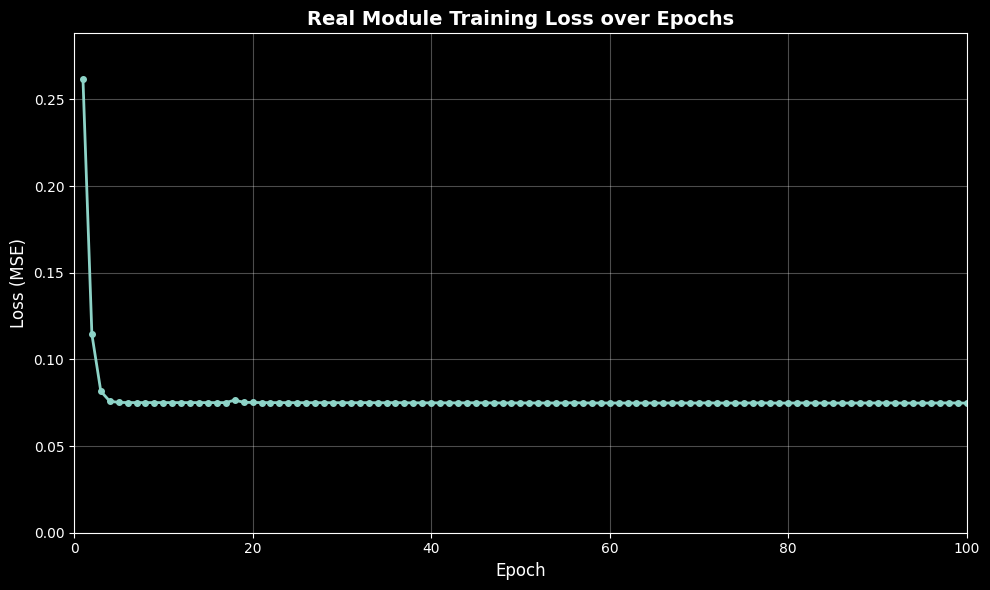

In [10]:
# * takes ~18m
epochs = 100
print("--- Starting Training for the Real NN Module ---")
loss_history = []  # Track losses for graphing

# ! if using .compile(), it is expected for the first epoch to take longer
for epoch in range(epochs):
    start = time.time()
    epoch_loss = 0.0
    Mod_Re_NN.train()

    for X_batch, Y_batch in train_loader_real:
        # Transfer data to GPU if possible
        X_batch, Y_batch = X_batch.to(device, non_blocking=True), Y_batch.to(device, non_blocking=True)

        optimizer_real.zero_grad(set_to_none=True)
        predictions = Mod_Re_NN(X_batch)
        loss = criterion(predictions, Y_batch)

        loss.backward()
        optimizer_real.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader_real)
    loss_history.append(avg_loss)  # Store loss for this epoch
    end = time.time()
    print(f"Real Module | Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.6f} | Time: {end - start:.2f} seconds")

print("Real NN Module Training Complete!")

# Plot loss vs epoch
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), loss_history, marker='o', linestyle='-', linewidth=2, markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Real Module Training Loss over Epochs', fontsize=14, fontweight='bold')
plt.xlim([0, epochs])
plt.ylim([0, max(loss_history) * 1.1])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Cell 7: Training Loop (Imaginary Module)

--- Starting Training for the Imaginary NN Module ---
Imaginary Module | Epoch 1/100 | Loss: 0.297470 | Time: 16.76 seconds
Imaginary Module | Epoch 2/100 | Loss: 0.118983 | Time: 15.96 seconds
Imaginary Module | Epoch 3/100 | Loss: 0.084591 | Time: 15.68 seconds
Imaginary Module | Epoch 4/100 | Loss: 0.076840 | Time: 16.56 seconds
Imaginary Module | Epoch 5/100 | Loss: 0.076632 | Time: 15.05 seconds
Imaginary Module | Epoch 6/100 | Loss: 0.076828 | Time: 15.05 seconds
Imaginary Module | Epoch 7/100 | Loss: 0.075003 | Time: 18.51 seconds
Imaginary Module | Epoch 8/100 | Loss: 0.074916 | Time: 18.33 seconds
Imaginary Module | Epoch 9/100 | Loss: 0.074924 | Time: 19.56 seconds
Imaginary Module | Epoch 10/100 | Loss: 0.075092 | Time: 17.80 seconds
Imaginary Module | Epoch 11/100 | Loss: 0.074891 | Time: 17.92 seconds
Imaginary Module | Epoch 12/100 | Loss: 0.074939 | Time: 15.66 seconds
Imaginary Module | Epoch 13/100 | Loss: 0.075152 | Time: 16.61 seconds
Imaginary Module | Epoch 14/100 

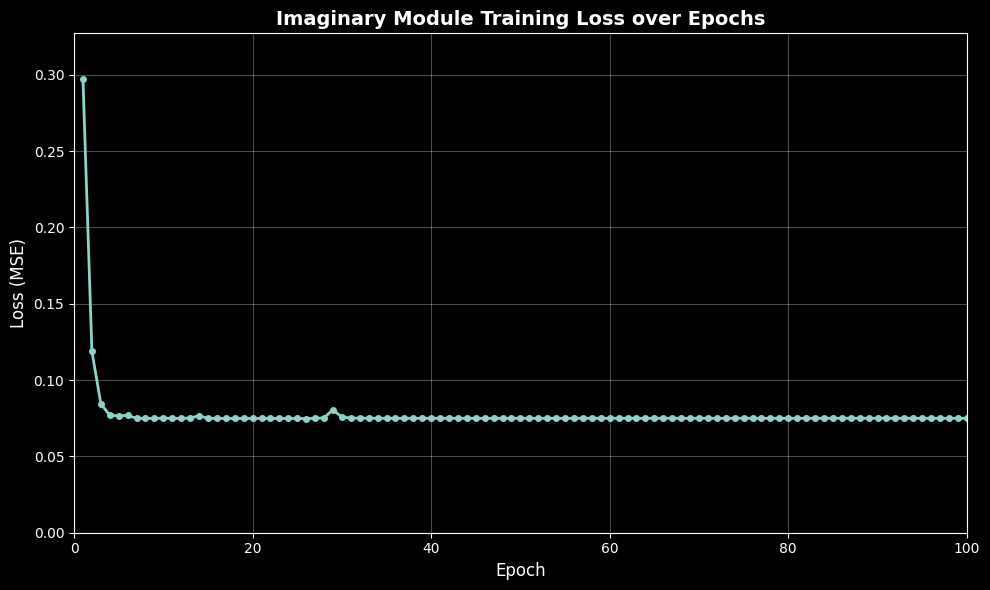

In [11]:
epochs = 100
print("--- Starting Training for the Imaginary NN Module ---")
loss_history = []  # Track losses for graphing

for epoch in range(epochs):
    start = time.time()
    epoch_loss = 0.0
    Mod_Im_NN.train()

    for X_batch, Y_batch in train_loader_imag:
        # Transfer data to GPU
        X_batch, Y_batch = X_batch.to(device, non_blocking=True), Y_batch.to(device, non_blocking=True)

        optimizer_imag.zero_grad(set_to_none=True)
        predictions = Mod_Im_NN(X_batch)
        loss = criterion(predictions, Y_batch)

        loss.backward()
        optimizer_imag.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader_imag)
    loss_history.append(avg_loss)  # Store loss for this epoch
    end = time.time()
    print(f"Imaginary Module | Epoch {epoch + 1}/{epochs} | Loss: {avg_loss:.6f} | Time: {end - start:.2f} seconds")

print("Imaginary NN Module Training Complete!")

# Plot loss vs epoch
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), loss_history, marker='o', linestyle='-', linewidth=2, markersize=4)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Imaginary Module Training Loss over Epochs', fontsize=14, fontweight='bold')
plt.xlim([0, epochs])
plt.ylim([0, max(loss_history) * 1.1])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Cell 8: Saving the Models

In [12]:
# Save the trained models
save_dir = "./trained_models/"
os.makedirs(save_dir, exist_ok=True)
# torch.save(Mod_Re_NN.state_dict(), os.path.join(save_dir, "16qam_mod_re_weights_80_20_dot02.pth"))
# torch.save(Mod_Im_NN.state_dict(), os.path.join(save_dir, "16qam_mod_im_weights_80_20_dot02.pth"))
torch.save(Mod_Re_NN.state_dict(), os.path.join(save_dir, "qpsk_mod_re_weights_80_20_dot005.pth"))
torch.save(Mod_Im_NN.state_dict(), os.path.join(save_dir, "qpsk_mod_im_weights_80_20_dot005.pth"))
print("\nTraining complete and weights saved!")


Training complete and weights saved!


Since we already saved the models, we can comment out most of the previous code blocks

Cell 9: Testing

In [13]:
# # 1. Load the Saved Models
# Test_Mod_Re = NNICFMapper(input_features).to(device)
# Test_Mod_Im = NNICFMapper(input_features).to(device)
#
# Test_Mod_Re.load_state_dict(torch.load("./trained_models/16qam_mod_re_weights.pth", weights_only=True))
# Test_Mod_Im.load_state_dict(torch.load("./trained_models/16qam_mod_im_weights.pth", weights_only=True))
# Test_Mod_Re.load_state_dict(torch.load("./trained_models/qpsk_mod_re_weights.pth", weights_only=True))
# Test_Mod_Im.load_state_dict(torch.load("./trained_models/qpsk_mod_im_weights.pth", weights_only=True))
#
# Test_Mod_Re.eval()
# Test_Mod_Im.eval()
#
# # 2. Grab one batch of data to test
# test_X_real, test_Y_real = torch.load("./data_pt/16qam_tx_rx_32_part_000_real.pt", weights_only=True)
# test_X_imag, test_Y_imag = torch.load("./data_pt/16qam_tx_rx_32_part_000_imag.pt", weights_only=True)
# test_X_real, test_Y_real = torch.load("./data_pt/qpsk_tx_rx_32_part_000_real.pt", weights_only=True)
# test_X_imag, test_Y_imag = torch.load("./data_pt/qpsk_tx_rx_32_part_000_imag.pt", weights_only=True)
#
# # 3. Generate Predictions (No gradients needed for testing)
# with torch.no_grad():
#     predicted_real = Test_Mod_Re(test_X_real).numpy()
#     predicted_imag = Test_Mod_Im(test_X_imag).numpy()
#
# # 4. Reconstruct the Complex OFDM Signals
# original_complex = test_X_real.numpy() + 1j * test_X_imag.numpy()
# clipped_complex = test_Y_real.numpy() + 1j * test_Y_imag.numpy()
# predicted_complex = predicted_real + 1j * predicted_imag

In [14]:
# 1. Load the Saved Models
Test_Mod_Re = NNICFMapper(input_features).to(device)
Test_Mod_Im = NNICFMapper(input_features).to(device)

# Test_Mod_Re.load_state_dict(torch.load("./trained_models/16qam_mod_re_weights_80_20_dot02.pth", weights_only=True))
# Test_Mod_Im.load_state_dict(torch.load("./trained_models/16qam_mod_im_weights_80_20_dot02.pth", weights_only=True))
Test_Mod_Re.load_state_dict(torch.load("./trained_models/qpsk_mod_re_weights_80_20_dot005.pth", weights_only=True))
Test_Mod_Im.load_state_dict(torch.load("./trained_models/qpsk_mod_im_weights_80_20_dot005.pth", weights_only=True))

Test_Mod_Re.eval()
Test_Mod_Im.eval()

# 2. Setup the Test Data (Files 80-99)
test_dataset_real = Subset(FastOFDMDataset("./data_pt/", part='real'), range(80, 100))
test_dataset_imag = Subset(FastOFDMDataset("./data_pt/", part='imag'), range(80, 100))

# We set shuffle=False to ensure real and imag batches stay perfectly aligned
test_loader_real = DataLoader(test_dataset_real, batch_size=None, shuffle=False)
test_loader_imag = DataLoader(test_dataset_imag, batch_size=None, shuffle=False)

# 3. Generate Predictions for all 20 test files
all_original, all_clipped, all_predicted = [], [], []

test_loss_real = 0.0
test_loss_imag = 0.0
with torch.no_grad():
    for (X_real, Y_real), (X_imag, Y_imag) in zip(test_loader_real, test_loader_imag):
        # Move inputs to device
        X_real, X_imag = X_real.to(device), X_imag.to(device)

        # Predict
        # ! Raises an error when when using .numpy()
        # pred_real = Test_Mod_Re(X_real).numpy()
        # pred_imag = Test_Mod_Im(X_imag).numpy()
        pred_real = Test_Mod_Re(X_real)
        pred_imag = Test_Mod_Im(X_imag)

        # Calculate the Loss for this batch
        loss_real = criterion(pred_real, Y_real)
        loss_imag = criterion(pred_imag, Y_imag)

        test_loss_real += loss_real.item()
        test_loss_imag += loss_imag.item()

        # Reconstruct complex signals
        orig_complex = X_real.numpy() + 1j * X_imag.numpy()
        clip_complex = Y_real.numpy() + 1j * Y_imag.numpy()
        pred_complex = pred_real + 1j * pred_imag

        all_original.append(orig_complex)
        all_clipped.append(clip_complex)
        all_predicted.append(pred_complex)

# Print the final average test metrics
avg_test_loss_real = test_loss_real / len(test_loader_real)
avg_test_loss_imag = test_loss_imag / len(test_loader_imag)

print("\n--- Test Set Metrics (20 Unseen Files) ---")
print(f"Average Real Module MSE Loss: {avg_test_loss_real:.6f}")
print(f"Average Imag Module MSE Loss: {avg_test_loss_imag:.6f}")

# 4. Concatenate the 20 batches into one massive array for evaluation
final_original_complex = np.concatenate(all_original, axis=0)
final_clipped_complex = np.concatenate(all_clipped, axis=0)
final_predicted_complex = np.concatenate(all_predicted, axis=0)

print(f"Testing complete! Aggregated {len(final_original_complex)} OFDM symbols.")


--- Test Set Metrics (20 Unseen Files) ---
Average Real Module MSE Loss: 0.074546
Average Imag Module MSE Loss: 0.074936
Testing complete! Aggregated 200000 OFDM symbols.


In [15]:
# # 5. Calculate PAPR (Peak-to-Average Power Ratio) for CCDF
# orig_papr, clip_papr, pred_papr = [], [], []
# orig_cm, clip_cm, pred_cm = [], [], []
#
# for i in range(len(original_complex)):
#     orig_papr.append(calculate_papr(original_complex[i]))
#     clip_papr.append(calculate_papr(clipped_complex[i]))
#     pred_papr.append(calculate_papr(predicted_complex[i]))
#     orig_cm.append(calculate_cm(original_complex[i]))
#     clip_cm.append(calculate_cm(clipped_complex[i]))
#     pred_cm.append(calculate_cm(predicted_complex[i]))
# orig_papr, clip_papr, pred_papr = np.array(orig_papr), np.array(clip_papr), np.array(pred_papr)
# orig_cm, clip_cm, pred_cm = np.array(orig_cm), np.array(clip_cm), np.array(pred_cm)
#
# # 6. Plot the CCDF
# labels = ['Original OFDM', 'Clipped OFDM', 'NNICF Predicted OFDM']
# plot_ccdf_compare([orig_papr, clip_papr, pred_papr], "Original vs Clipped vs NNICF Predicted OFDM", labels)
# plot_ccdf_compare([orig_cm, clip_cm, pred_cm], "Original vs Clipped vs NNICF Predicted OFDM", labels, metric="CM")

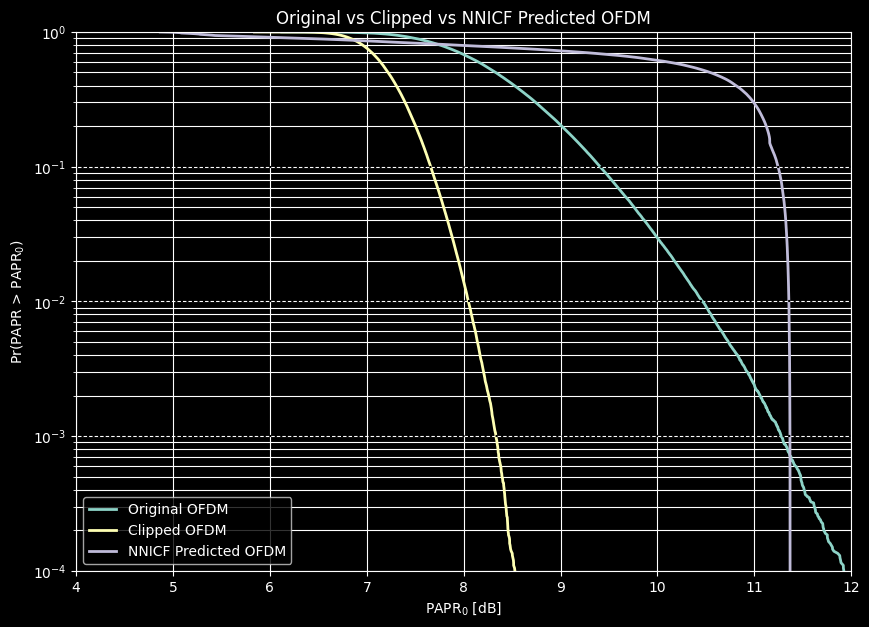

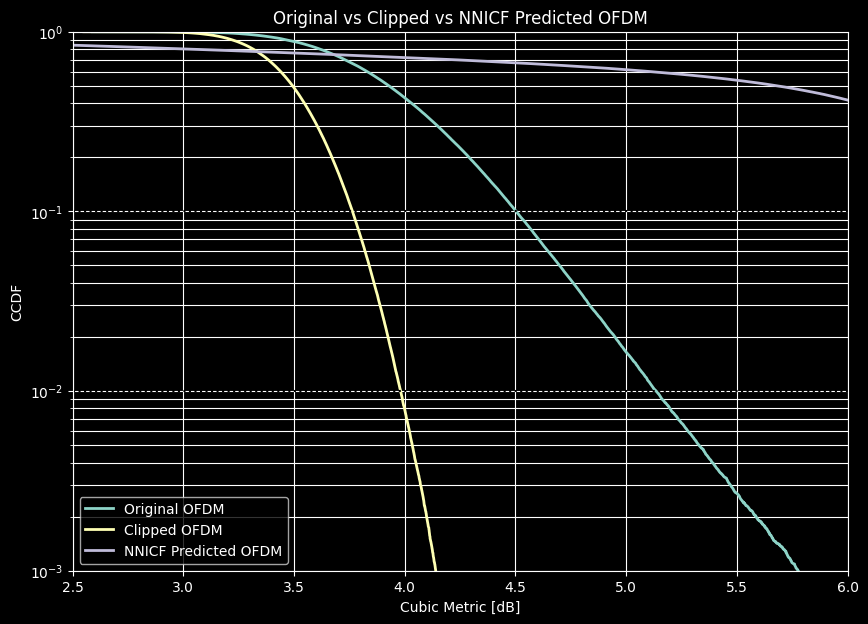

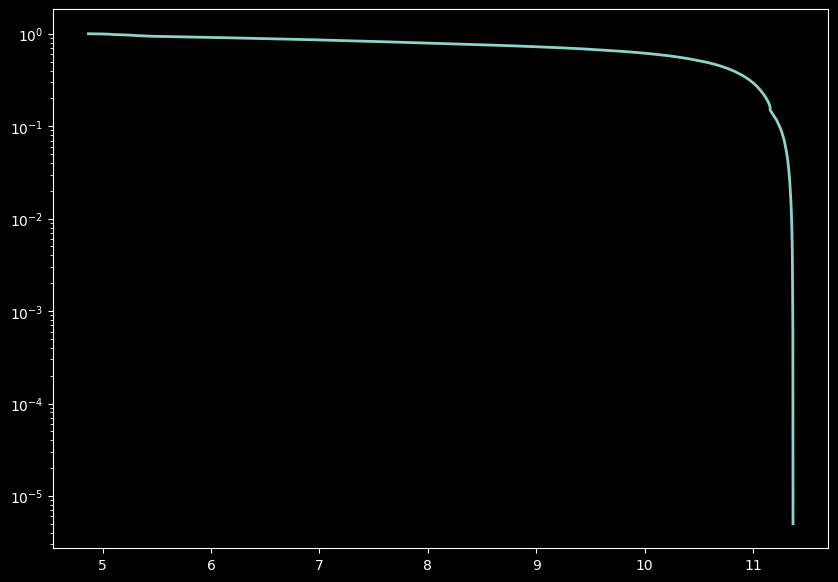

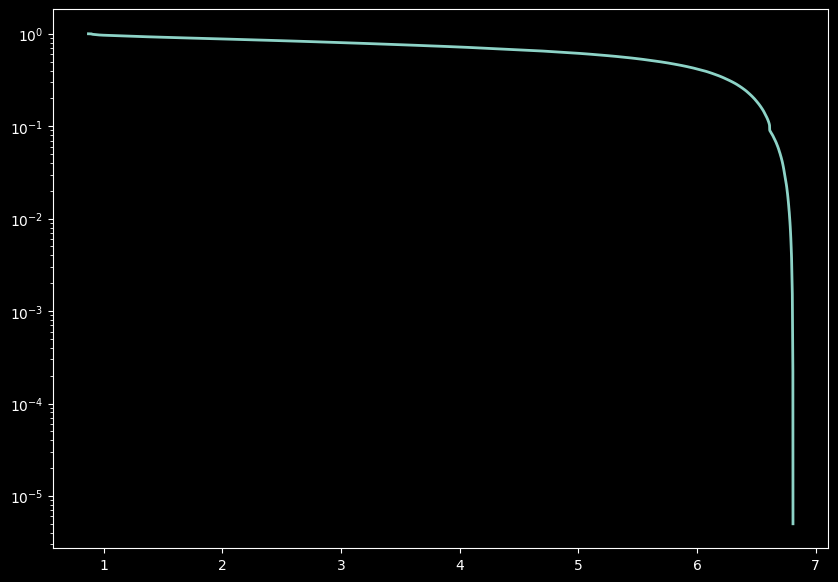

In [16]:
# 5. Calculate PAPR and CM for all test symbols
orig_papr, clip_papr, pred_papr = [], [], []
orig_cm, clip_cm, pred_cm = [], [], []

# Iterate through the massive aggregated arrays
for i in range(len(final_original_complex)):
    orig_papr.append(calculate_papr(final_original_complex[i]))
    clip_papr.append(calculate_papr(final_clipped_complex[i]))
    pred_papr.append(calculate_papr(final_predicted_complex[i]))

    orig_cm.append(calculate_cm(final_original_complex[i]))
    clip_cm.append(calculate_cm(final_clipped_complex[i]))
    pred_cm.append(calculate_cm(final_predicted_complex[i]))

orig_papr, clip_papr, pred_papr = np.array(orig_papr), np.array(clip_papr), np.array(pred_papr)
orig_cm, clip_cm, pred_cm = np.array(orig_cm), np.array(clip_cm), np.array(pred_cm)

# 6. Plot the CCDF
labels = ['Original OFDM', 'Clipped OFDM', 'NNICF Predicted OFDM']
plot_ccdf_compare([orig_papr, clip_papr, pred_papr], "Original vs Clipped vs NNICF Predicted OFDM", labels)
plot_ccdf_compare([orig_cm, clip_cm, pred_cm], "Original vs Clipped vs NNICF Predicted OFDM", labels, metric="CM")

plt.figure(figsize=(10, 7))
sorted_papr = np.sort(pred_papr)
y_axis = np.arange(len(sorted_papr), 0, -1) / len(sorted_papr) # ? why dont we use the theoretical CCDF function
plt.semilogy(sorted_papr, y_axis, linewidth=2)
plt.show()
plt.figure(figsize=(10, 7))
sorted_cm = np.sort(pred_cm)
y_axis = np.arange(len(sorted_cm), 0, -1) / len(sorted_cm) # ? why dont we use the theoretical CCDF function
plt.semilogy(sorted_cm, y_axis, linewidth=2)
plt.show()